In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_parquet(
    "../data/processed/features.parquet"
)

In [13]:
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(df.shape)
print("\n")

DATASET SHAPE
(289774, 65)




In [14]:
print("=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)
print(
    df["batting_team_won"]
    .value_counts(normalize=True)
)
print("\n")

TARGET DISTRIBUTION
batting_team_won
0    0.589359
1    0.410641
Name: proportion, dtype: float64




In [15]:
print("=" * 60)
print("REQUIRED RUN RATE CHECK")
print("=" * 60)
print(
    df.groupby("innings")
    ["required_run_rate"]
    .mean()
)
print("\n")

REQUIRED RUN RATE CHECK
innings
1     0.000000
2    10.087939
Name: required_run_rate, dtype: float64




In [16]:
print("=" * 60)
print("MOMENTUM FEATURE CHECK")
print("=" * 60)

assert (
    df["runs_last_6"]
    <= df["runs_last_18"]
).all(), "Momentum feature bug detected"

print("Momentum features: OK")

print("\n")

MOMENTUM FEATURE CHECK
Momentum features: OK




In [17]:
print("=" * 60)
print("NULL VALUE CHECK")
print("=" * 60)

nulls = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

print(
    nulls[nulls > 0]
)

print("\n")

NULL VALUE CHECK
wicket_type       275407
match_number       16713
city               11612
reserve_umpire      5494
tv_umpire            930
dtype: int64




In [18]:
print("=" * 60)
print("FEATURE CORRELATIONS WITH TARGET")
print("=" * 60)

exclude_cols = [
    "match_id"
]

numeric_cols = [
    col
    for col in df.select_dtypes(
        include=[np.number]
    ).columns
    if col not in exclude_cols
]

corr = (
    df[numeric_cols]
    .corr()["batting_team_won"]
    .sort_values()
)

print("\nTop Positive Features")
print(corr.tail(10))

print("\nTop Negative Features")
print(corr.head(10))

print("\n")

FEATURE CORRELATIONS WITH TARGET

Top Positive Features
boundaries_last_6    0.094645
runs_last_6          0.104854
partnership_balls    0.126518
runs_last_18         0.126923
season               0.132383
momentum_index       0.141397
partnership_runs     0.151978
current_run_rate     0.163569
wickets_in_hand      0.204291
batting_team_won     1.000000
Name: batting_team_won, dtype: float64

Top Negative Features
run_rate_pressure   -0.256905
cum_wickets_after   -0.206006
wickets_lost_pct    -0.204291
cum_wickets         -0.204291
wickets_last_18     -0.144907
required_run_rate   -0.119869
dots_last_6         -0.080085
is_dot              -0.039918
required_runs       -0.039609
is_wicket           -0.039543
Name: batting_team_won, dtype: float64




FEATURE DISTRIBUTIONS


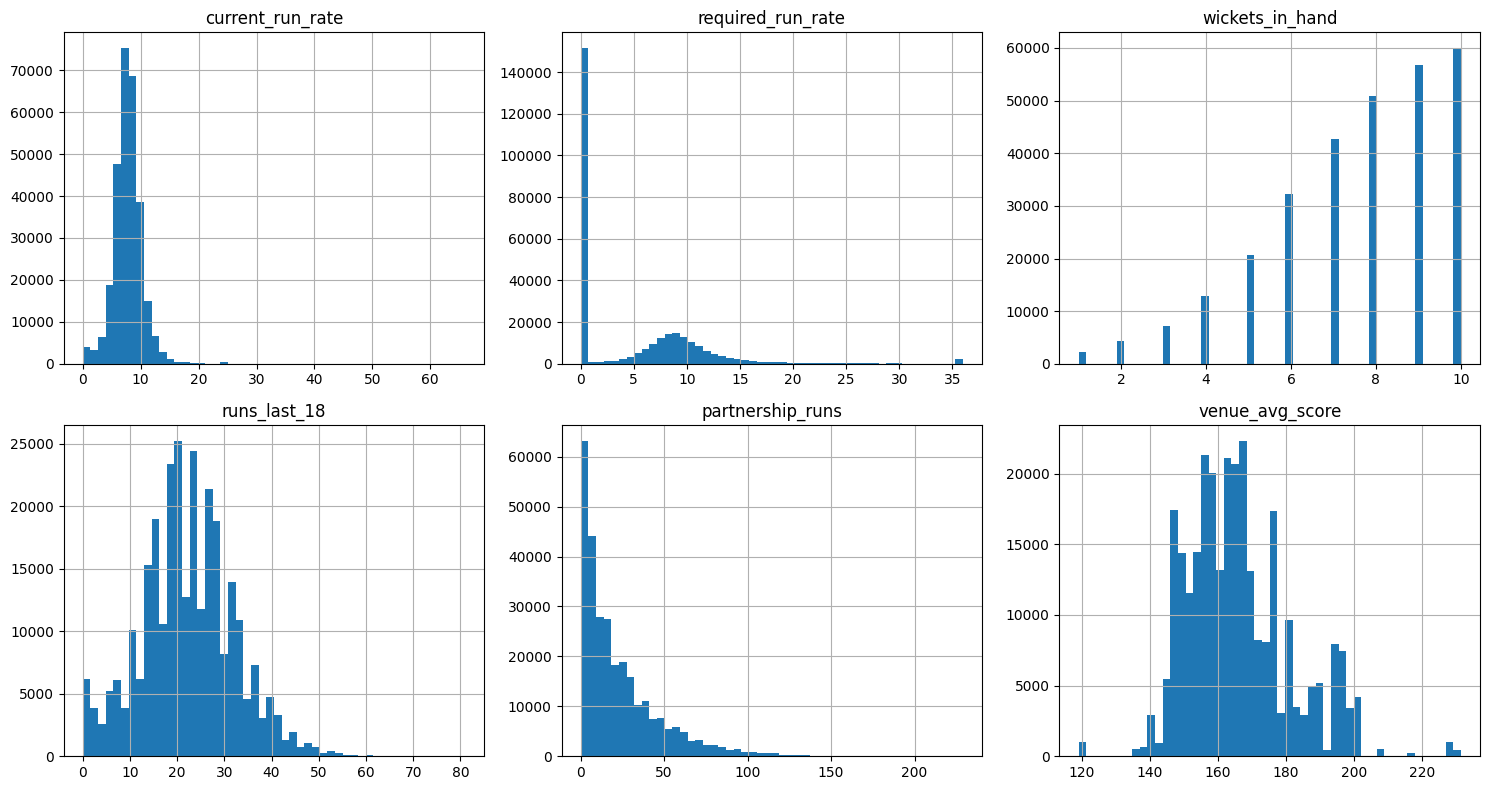

In [19]:
print("=" * 60)
print("FEATURE DISTRIBUTIONS")
print("=" * 60)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

features_to_plot = [
    "current_run_rate",
    "required_run_rate",
    "wickets_in_hand",
    "runs_last_18",
    "partnership_runs",
    "venue_avg_score"
]

for ax, feature in zip(
    axes.flatten(),
    features_to_plot
):
    df[feature].hist(
        bins=50,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()

plt.savefig(
    "feature_distributions.png",
    dpi=150
)

plt.show()

print("\n")


In [20]:
print("=" * 60)
print("FEATURE SAMPLE")
print("=" * 60)

cols = [
    "match_id",
    "innings",
    "target",
    "current_run_rate",
    "required_run_rate",
    "wickets_in_hand",
    "runs_last_6",
    "runs_last_18",
    "momentum_index",
    "venue_avg_score",
    "batting_team_won"
]

print(df[cols].head())

FEATURE SAMPLE
  match_id  innings  target  current_run_rate  required_run_rate  \
0  1082591        1     208               0.0                0.0   
1  1082591        1     208               0.0                0.0   
2  1082591        1     208               8.0                0.0   
3  1082591        1     208               6.0                0.0   
4  1082591        1     208               9.0                0.0   

   wickets_in_hand  runs_last_6  runs_last_18  momentum_index  \
0               10          0.0           0.0             0.0   
1               10          0.0           0.0             0.0   
2               10          4.0           4.0             4.0   
3               10          4.0           4.0             4.0   
4               10          6.0           6.0             6.0   

   venue_avg_score  batting_team_won  
0       154.512195                 1  
1       154.512195                 1  
2       154.512195                 1  
3       154.512195           